# Data Cleaning & Feature Engineering
## Nairobi House Price Prediction

This notebook covers data cleaning, preprocessing, and feature engineering for the house price prediction model.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries imported successfully')

Matplotlib is building the font cache; this may take a moment.


✅ Libraries imported successfully


## 2. Load and Explore Data

In [2]:
# Load the demo dataset
df = pd.read_csv('../data/raw/all_listings_demo.csv')

print(f"📊 Dataset Shape: {df.shape}")
print(f"\n📋 Column Info:")
print(df.info())
print(f"\n📈 First few rows:")
df.head()

📊 Dataset Shape: (800, 12)

📋 Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   source         800 non-null    str  
 1   listing_id     800 non-null    str  
 2   title          800 non-null    str  
 3   location       800 non-null    str  
 4   property_type  800 non-null    str  
 5   bedrooms       800 non-null    int64
 6   bathrooms      800 non-null    int64
 7   size_sqft      800 non-null    int64
 8   price_kes      800 non-null    int64
 9   amenities      478 non-null    str  
 10  listing_url    800 non-null    str  
 11  scrape_date    800 non-null    str  
dtypes: int64(4), str(8)
memory usage: 75.1 KB
None

📈 First few rows:


,source,listing_id,title,location,property_type,bedrooms,bathrooms,size_sqft,price_kes,amenities,listing_url,scrape_date
0,DiamondTrust,A0000,3BR Apartment in Ongata Rongai,Ongata Rongai,Apartment,3,2,1173,21850876,NaN,https://example.com/property/0,2026-01-23
1,BuyRentKenya,B0001,1BR Townhouse in Runda,Runda,Townhouse,1,1,1011,68839086,NaN,https://example.com/property/1,2026-01-27
2,BuyRentKenya,C0002,3BR Villa in Kileleshwa,Kileleshwa,Villa,3,3,2497,38227887,NaN,https://example.com/property/2,2026-01-25
3,BuyRentKenya,D0003,3BR House in Kileleshwa,Kileleshwa,House,3,3,2238,29325823,lift|pool,https://example.com/property/3,2026-01-29
4,BuyRentKenya,E0004,3BR Townhouse in Runda,Runda,Townhouse,3,2,1646,114841361,pool|gym|garden,https://example.com/property/4,2026-01-23


In [3]:
# Summary statistics
print("📊 Summary Statistics:")
df.describe()

📊 Summary Statistics:


,bedrooms,bathrooms,size_sqft,price_kes
count,800.000000,800.000000,800.00000,8.000000e+02
mean,2.711250,2.310000,1741.02500,2.912479e+07
std,1.035236,0.992538,905.68198,3.414381e+07
min,1.000000,1.000000,452.00000,2.500000e+06
25%,2.000000,2.000000,1097.00000,9.084294e+06
50%,3.000000,2.000000,1415.00000,1.549222e+07
75%,3.000000,3.000000,2217.00000,3.661946e+07
max,5.000000,5.000000,6006.00000,2.270171e+08


In [4]:
# Check for missing values
print("❌ Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
print(missing_df[missing_df['Missing_Count'] > 0])

❌ Missing Values:
      Column  Missing_Count  Missing_Percentage
9  amenities            322               40.25


## 3. Handle Missing Values

In [5]:
# Create a working copy
df_clean = df.copy()

# Fill missing amenities with 'None'
df_clean['amenities'] = df_clean['amenities'].fillna('None')

# Drop rows with missing critical values
critical_cols = ['price_kes', 'bedrooms', 'bathrooms', 'size_sqft', 'location']
df_clean = df_clean.dropna(subset=critical_cols)

print(f"✅ After handling missing values: {len(df_clean)} records (removed {len(df) - len(df_clean)} rows)")

✅ After handling missing values: 800 records (removed 0 rows)


## 4. Remove Duplicates

In [6]:
# Check for duplicates
duplicates_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['listing_id'])
duplicates_removed = duplicates_before - len(df_clean)

print(f"✅ Duplicates removed: {duplicates_removed}")
print(f"   Final dataset size: {len(df_clean)} records")

✅ Duplicates removed: 0
   Final dataset size: 800 records


## 5. Detect and Handle Outliers

In [7]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)

# Find outliers in price
price_outliers = detect_outliers_iqr(df_clean, 'price_kes')
print(f"⚠️  Price outliers detected: {price_outliers.sum()}")

# Optional: Remove extreme outliers (top/bottom 1%)
price_p1 = df_clean['price_kes'].quantile(0.01)
price_p99 = df_clean['price_kes'].quantile(0.99)

print(f"\n💰 Price Range:")
print(f"   1st percentile: KES {price_p1:,.0f}")
print(f"   99th percentile: KES {price_p99:,.0f}")
print(f"   Original min: KES {df_clean['price_kes'].min():,.0f}")
print(f"   Original max: KES {df_clean['price_kes'].max():,.0f}")

⚠️  Price outliers detected: 60

💰 Price Range:
   1st percentile: KES 3,078,035
   99th percentile: KES 175,068,076
   Original min: KES 2,500,000
   Original max: KES 227,017,145


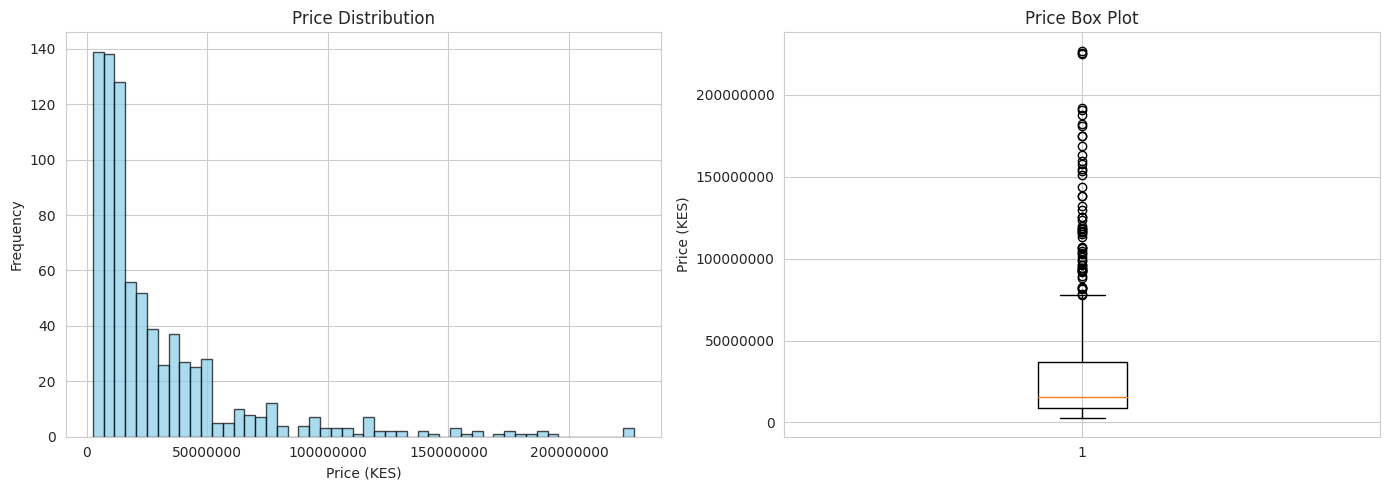

✅ Outliers visualized


In [8]:
# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['price_kes'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Price (KES)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].ticklabel_format(style='plain', axis='x')

# Box plot
axes[1].boxplot(df_clean['price_kes'])
axes[1].set_ylabel('Price (KES)')
axes[1].set_title('Price Box Plot')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print("✅ Outliers visualized")

## 6. Encode Categorical Variables

In [9]:
# Create encoded copy for modeling
df_encoded = df_clean.copy()

# Label encode location
le_location = LabelEncoder()
df_encoded['location_encoded'] = le_location.fit_transform(df_encoded['location'])

# Label encode property_type
le_property = LabelEncoder()
df_encoded['property_type_encoded'] = le_property.fit_transform(df_encoded['property_type'])

print(f"✅ Categorical variables encoded:")
print(f"\n📍 Locations ({len(le_location.classes_)}):")
for i, loc in enumerate(le_location.classes_):
    print(f"   {i}: {loc}")

print(f"\n🏠 Property Types ({len(le_property.classes_)}):")
for i, ptype in enumerate(le_property.classes_):
    print(f"   {i}: {ptype}")

✅ Categorical variables encoded:

📍 Locations (19):
   0: Buruburu
   1: Donholm
   2: Embakasi
   3: Karen
   4: Kasarani
   5: Kileleshwa
   6: Kilimani
   7: Kitengela
   8: Komarock
   9: Langata
   10: Lavington
   11: Ngong
   12: Ongata Rongai
   13: Parklands
   14: Runda
   15: Syokimau
   16: Thika Road
   17: Upper Hill
   18: Westlands

🏠 Property Types (5):
   0: Apartment
   1: Bungalow
   2: House
   3: Townhouse
   4: Villa


## 7. Scale Numerical Features

In [10]:
# Select numerical features for scaling
numerical_features = ['bedrooms', 'bathrooms', 'size_sqft']

# Create scaler
scaler = StandardScaler()

# Fit and transform
df_scaled = df_encoded.copy()
df_scaled[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print(f"✅ Numerical features scaled using StandardScaler")
print(f"\nScaled feature statistics:")
print(df_scaled[numerical_features].describe())

✅ Numerical features scaled using StandardScaler

Scaled feature statistics:
           bedrooms     bathrooms     size_sqft
count  8.000000e+02  8.000000e+02  8.000000e+02
mean  -1.332268e-16 -2.775558e-17 -1.043610e-16
std    1.000626e+00  1.000626e+00  1.000626e+00
min   -1.654039e+00 -1.320675e+00 -1.424155e+00
25%   -6.874714e-01 -3.125260e-01 -7.115388e-01
50%    2.790965e-01 -3.125260e-01 -3.602025e-01
75%    2.790965e-01  6.956225e-01  5.258720e-01
max    2.212232e+00  2.711920e+00  4.712077e+00


## 8. Create New Features

In [11]:
# Feature engineering
df_features = df_encoded.copy()

# 1. Price per bedroom
df_features['price_per_bed'] = df_features['price_kes'] / (df_features['bedrooms'] + 1)

# 2. Price per sqft
df_features['price_per_sqft'] = df_features['price_kes'] / (df_features['size_sqft'] + 1)

# 3. Bedroom to bathroom ratio
df_features['bed_bath_ratio'] = df_features['bedrooms'] / (df_features['bathrooms'] + 1)

# 4. Total rooms (beds + baths)
df_features['total_rooms'] = df_features['bedrooms'] + df_features['bathrooms']

# 5. Has amenities flag
df_features['has_amenities'] = (df_features['amenities'] != 'None').astype(int)

# 6. Amenity count
df_features['amenity_count'] = df_features['amenities'].apply(
    lambda x: len(str(x).split('|')) if x != 'None' else 0
)

print(f"✅ New features created:")
print(f"   - price_per_bed")
print(f"   - price_per_sqft")
print(f"   - bed_bath_ratio")
print(f"   - total_rooms")
print(f"   - has_amenities")
print(f"   - amenity_count")

print(f"\n📊 New features preview:")
print(df_features[['price_per_bed', 'price_per_sqft', 'bed_bath_ratio', 'amenity_count']].head())

✅ New features created:
   - price_per_bed
   - price_per_sqft
   - bed_bath_ratio
   - total_rooms
   - has_amenities
   - amenity_count

📊 New features preview:
   price_per_bed  price_per_sqft  bed_bath_ratio  amenity_count
0     5462719.00    18612.330494            1.00              0
1    34419543.00    68022.812253            0.50              0
2     9556971.75    15303.397518            0.75              0
3     7331455.75    13097.732470            0.75              2
4    28710340.25    69727.602307            1.00              3


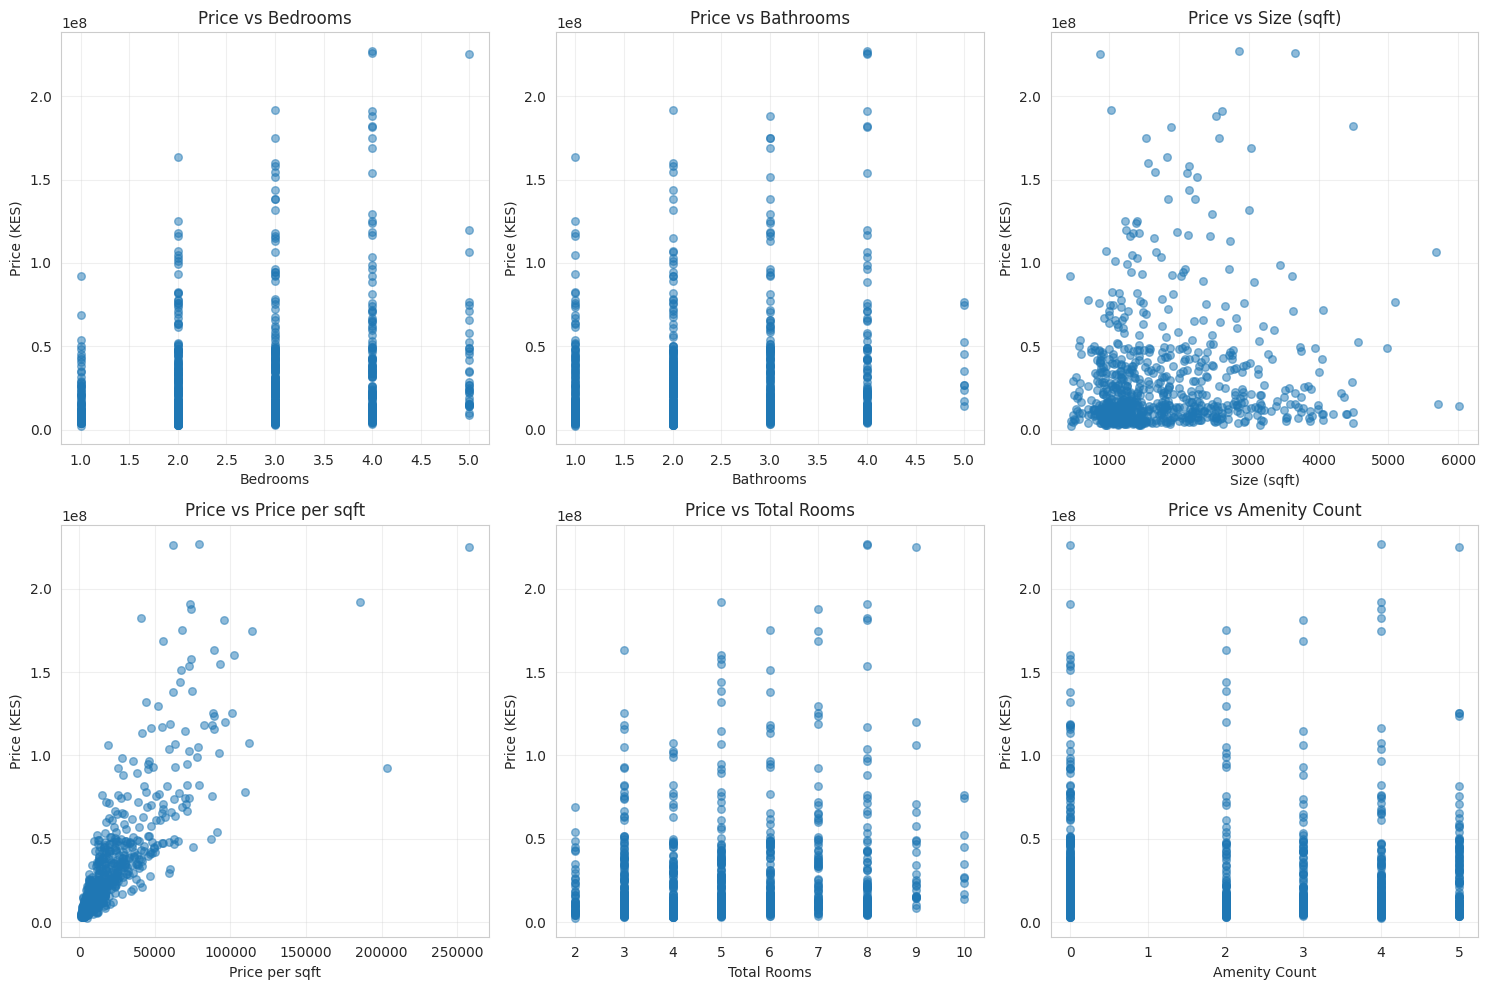

✅ Feature relationships visualized


In [12]:
# Visualize feature correlations with price
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot price vs each feature
features_to_plot = [
    ('bedrooms', 'Bedrooms'),
    ('bathrooms', 'Bathrooms'),
    ('size_sqft', 'Size (sqft)'),
    ('price_per_sqft', 'Price per sqft'),
    ('total_rooms', 'Total Rooms'),
    ('amenity_count', 'Amenity Count')
]

for idx, (feature, title) in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    ax.scatter(df_features[feature], df_features['price_kes'], alpha=0.5, s=30)
    ax.set_xlabel(title)
    ax.set_ylabel('Price (KES)')
    ax.set_title(f'Price vs {title}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Feature relationships visualized")

## 9. Split Data into Training and Testing Sets

In [13]:
# Select features for modeling
feature_cols = [
    'bedrooms', 'bathrooms', 'size_sqft',
    'location_encoded', 'property_type_encoded',
    'price_per_bed', 'price_per_sqft', 'bed_bath_ratio',
    'total_rooms', 'has_amenities', 'amenity_count'
]

X = df_features[feature_cols].copy()
y = df_features['price_kes'].copy()

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data split complete:")
print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Testing set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n📊 Features used: {len(feature_cols)}")
print(f"   {feature_cols}")

print(f"\n💰 Price range in training set:")
print(f"   Min: KES {y_train.min():>15,.0f}")
print(f"   Max: KES {y_train.max():>15,.0f}")
print(f"   Mean: KES {y_train.mean():>15,.0f}")

✅ Data split complete:
   Training set: 640 samples (80.0%)
   Testing set: 160 samples (20.0%)

📊 Features used: 11
   ['bedrooms', 'bathrooms', 'size_sqft', 'location_encoded', 'property_type_encoded', 'price_per_bed', 'price_per_sqft', 'bed_bath_ratio', 'total_rooms', 'has_amenities', 'amenity_count']

💰 Price range in training set:
   Min: KES       2,500,000
   Max: KES     227,017,145
   Mean: KES      28,763,820


In [14]:
# Summary
print("\n" + "="*70)
print("✅ DATA CLEANING & FEATURE ENGINEERING COMPLETE")
print("="*70)
print(f"\n📊 Final Dataset:")
print(f"   Total records: {len(df_features)}")
print(f"   Features: {len(feature_cols)}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"\n✨ Ready for model training!")


✅ DATA CLEANING & FEATURE ENGINEERING COMPLETE

📊 Final Dataset:
   Total records: 800
   Features: 11
   Training samples: 640
   Test samples: 160

✨ Ready for model training!
